<a href="https://colab.research.google.com/github/SotaYoshida/Lecture_DataScience/blob/master/Python_chapter9_Probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 確率と(疑似)乱数


### 疑似乱数について

コンピュータで何かの処理を実現したいときや、自然科学や統計学などで様々なことをシミュレーションしたいとき、[確率的な事象]を考えたくなることがよくあります。  

たとえば人◯ゲームのようなゲームを作るときにはサイコロの出目が必要になりますし、技が急所に当たる確率や色違いのポ◯モンが出現する確率などを設定しなければなりません.

真に理想的なサイコロならば1から6の目が出る確率は等しく1/6ですが、このようなサイコロは、現実世界でも、コンピュータの上でも実現することはできず、我々人間が乱数をシミュレーションして扱う際には、何らかの確定的な方法で乱数列を生成することになります。

真の意味での乱数と区別する意味で、我々が普段ゲームなどで扱う乱数は擬似乱数と呼ばれるべきものです。
(以下ではめんどくさいので、単に乱数と呼ぶことにします)


c.f. [モンテカルロ法]と検索すると、(主に学術的な分野で)乱数がどのように活用されているか、雰囲気を味わうことができます。私がこれまで書いた論文でも、どれも(広義の)モンテカルロ法を使用しています(ちなみにモンテカルロはカジノで有名なモナコの地名Monte Carloに由来).


Pythonではrandomモジュールをインポートすれば乱数を使用することができます。  
(numpyにも```numpy.random```という下位のモジュールがあるので、以下のrandomをnumpy.random(いつもどおりあだ名をつけるならnp.random)としても多くの場合では互換性があるはずです。

In [53]:
import random

たとえばサイコロの例でいうと...

In [54]:
random.randint(1,6)

1

のようにrandom.randint(最小値,最大値)とすると,指定した閉区間の整数値をランダムに生成することができる。
今の場合、最小値に１、最大値に6を採用したことで、この乱数をサイコロの出目とみなすことができる。

100個のサイコロの出目を保持しておきたければ

In [55]:
a = [random.randint(1,6) for i in range(100)]
print(a)

[4, 5, 3, 6, 4, 4, 1, 4, 5, 5, 3, 6, 5, 6, 6, 4, 1, 5, 1, 4, 3, 1, 3, 1, 6, 6, 4, 3, 5, 1, 5, 3, 6, 4, 6, 3, 4, 5, 4, 1, 3, 4, 3, 4, 3, 2, 6, 2, 2, 2, 4, 4, 6, 3, 3, 5, 1, 2, 6, 2, 1, 5, 4, 5, 2, 2, 4, 3, 6, 3, 2, 4, 3, 1, 1, 5, 1, 4, 5, 3, 5, 5, 3, 3, 6, 1, 1, 3, 5, 5, 1, 5, 3, 2, 4, 2, 6, 3, 6, 4]



などとすればよい。
30回振った場合と50万回振った場合の出目をヒストグラムにしてみると...1-6の出る目の頻度が確率から期待される振る舞いに漸近していく事がわかる.





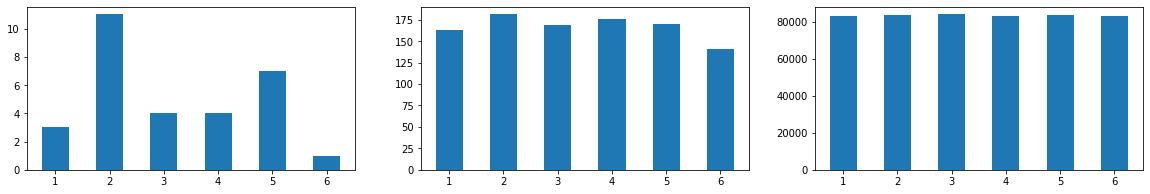

In [75]:
from matplotlib import pyplot as plt

a = [random.randint(1,6) for i in range(30)]
b = [random.randint(1,6) for i in range(1000)]
c = [random.randint(1,6) for i in range(500000)]

fig = plt.figure(figsize=(20,3))
axL = fig.add_subplot(131)
axM = fig.add_subplot(132)
axR = fig.add_subplot(133)
tbin = np.arange(0.5,7.5,1) #binの始点を定義
axL.hist(a,align='mid',bins=tbin,rwidth=0.5) #ビン幅を始点から右(r)に0.5と指定
axM.hist(b,align='mid',bins=tbin,rwidth=0.5)
axR.hist(c,align='mid',bins=tbin,rwidth=0.5)
plt.show()
plt.close()

以下では、randomモジュールのよく使う(?)機能をいくつか紹介する.

#### 無作為抽出

リストやrangeなどからランダムに要素を選びたいとき  
(たとえば[出席番号のリストからランダムに選ぶ]などのイメージ)
には```random.choice```が便利です。

In [57]:
a = random.choice([1,3,5,6]) ## 引数(リスト)からランダムに要素を抽出する
b = random.choice(range(100)) ## 引数(range(0から99))からランダムに要素を抽出する
print("a", a, "b", b)

a 6 b 16


0から99までの100個の整数値から重複を許さずに10個選びたい、といった場合は、numpy.randomの関数を使うのがよい。

In [58]:
import numpy as np
np.random.choice(range(100),10,replace=False) # replace = True/Falseで重複を認めるかどうかを指定できる 

array([46, 99, 48, 84, 37, 13,  0, 26, 30,  6])

(上の関数のreplace=True/Falseを変えて何回か実行してみて、抽出された数に重複があるかどうかを確かめてみよう)

#### 一様分布からの乱数生成


In [59]:
random.uniform(1,10) #[1,10)または[1,10]からの一様乱数 (randomモジュールでは半開区間/閉区間どちらになるかはroundingに依存するらしい)

2.097801633700902

xとyの値を[-1,1]の範囲でランダムに生成してplotしてみよう

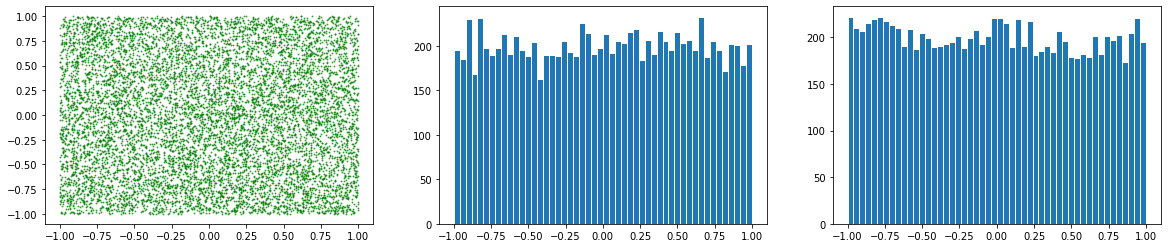

In [77]:
num = 10000
xs = [ random.uniform(-1,1) for i in range(num)]
ys = [ random.uniform(-1,1) for i in range(num)]

fig = plt.figure(figsize=(20,4))
axs = [fig.add_subplot(131),fig.add_subplot(132),fig.add_subplot(133)]
axs[0].scatter(xs,ys,color="green",s=1,alpha=0.6) #散布図
axs[1].hist(xs,bins=50,ec="w") #xのヒストグラム (注:binの数50はいい加減に選んだ)
axs[2].hist(ys,bins=50,ec="w") #yのヒストグラム
plt.show()
plt.close()

#### 正規分布からの乱数生成



正規分布には、多くの優れた特徴を有しています. それらは後述するとして、正規分布に従う乱数を生成するには```random.gauss()```もしくは```random.normalvariate()```を用いればよい(両者は基本的に同じだが、前者のほうが高速らしい).

In [61]:
a = random.gauss(0.0, 1.0) #平均0.0,標準偏差1.0の正規分布からの乱数生成

正規分布になっているかチェック

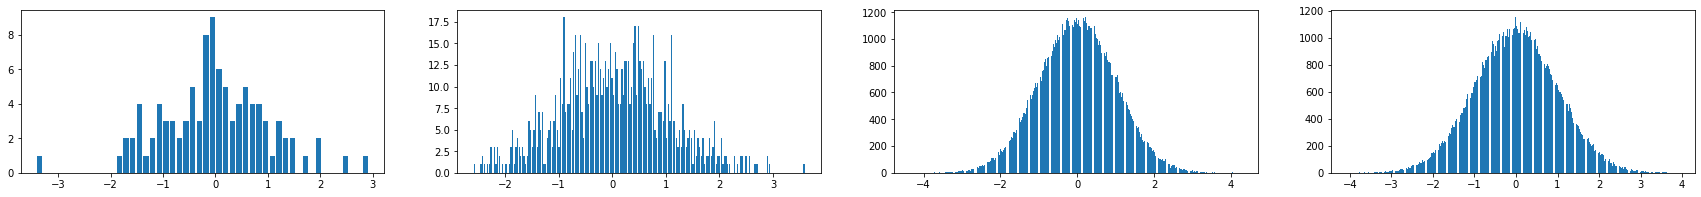

mu,sigma a: -0.015705787313374294 1.0051915439041346
mu,sigma b: 0.03636463417348347 1.0044484229593045
mu,sigma c: -0.00030187339639436446 0.9996933416100153
mu,sigma c: -0.00253081543691318 0.9976439672996259


In [62]:
Na = 100; Nb = 1000; Nc = 100000
a = [ random.gauss(0.0, 1.0) for i in range(Na)] 
b = [ random.gauss(0.0, 1.0) for i in range(Nb)] 
c = [ random.gauss(0.0, 1.0) for i in range(Nc)] 
c2 = [ random.normalvariate(0.0, 1.0) for i in range(Nc)]  #一応normalvariateも使ってみる

fig = plt.figure(figsize=(30,3))
axs = [ fig.add_subplot(141),fig.add_subplot(142),fig.add_subplot(143),fig.add_subplot(144)]
axs[0].hist(a,align='mid',bins=50,rwidth=0.8)
axs[1].hist(b,align='mid',bins=200,rwidth=0.8)
axs[2].hist(c,align='mid',bins=300,rwidth=0.8)
axs[3].hist(c2,align='mid',bins=300,rwidth=0.8)
plt.show()
plt.close()

print("mu,sigma a:",np.mean(a), np.std(a))
print("mu,sigma b:",np.mean(b), np.std(b))
print("mu,sigma c:",np.mean(c), np.std(c))
print("mu,sigma c:",np.mean(c2), np.std(c2))

サンプル数が増えるにつれて、正規分布に収束していく様子が見られる. 

(c.f. 中心極限定理)

#### 乱数の種(seed)の固定

これまでのプログラムでは、実行の度に答えが変わった.  

擬似的にでもランダム性が担保されているというのは、便利だが、実際にプログラミングで乱数を使って何かの作業を実装したいときは、何か直感と反するような振る舞いをコードが示した際、それがランダム性からくる偶然の挙動なのか、コードにバグがあるせいなのかを特定したくなる。  
そんなときには、
```random.seed(適当な整数値)```   
を使って乱数の"種"を指定することで、再現性のあるコードにすることができます。  
たとえばサイコロの例でいうと

In [63]:
[ random.randint(1,6) for i in range(10)]

[4, 1, 1, 3, 2, 4, 4, 4, 2, 4]

は実行する度に答えが変わるが

In [64]:
random.seed(1234) 
[ random.randint(1,6) for i in range(10)]

[4, 1, 1, 1, 5, 1, 6, 6, 1, 1]

は何度実行しても同じ答えになる。これは、乱数の生成前に"種"を指定しているため。

イメージとしては、「無限に長い疑似乱数の羅列の中から10個並んだ数を選ぶときに、どこからどこまでを抽出するかを指定する」のが、この```random.seed```関数です(細かいことをいうと少し不正確ですが、だいたいこんなイメージ).

古いゲームだと、起動してからの経過時間が乱数の種になっていることが多いようで、このパターンを調べることができれば、原理的には(つまり1/60秒程度の正確な入力が可能なら)望むようにゲームをスイスイ攻略することもできます。

これを利用して攻略を進めたり、コンピュータにゲームの操作をやらせて、メタル◯ライムに会心の一撃を食らわせてレベルアップしまくる動画などが昔はやりました(今も時々ある)。




#### じゃんけん関数



じゃんけんをする関数を作ってみましょう。

In [65]:
def Janken( ):    
    r = ["グー","チョキ","パー"]
    return r[random.randint(0,2)] 

In [66]:
Janken()

'チョキ'

今の場合は、単に1/3の確率で手を選ぶ関数ですが、これを拡張していけば[１つ前の自分の手(あるいは相手の手)に応じて次に何を出すか]といった、確率を1/3から変動させた実装もできます。

桜美林大学の芳沢光雄教授の学生に対する調査によるとグーは35.0%、 チョキは31.7%、 パーは33.3%になったそうです。また、あいこの場合に2回続けて同じ手を出す割合は、22.8％だったそうです([芳沢光雄 じゃんけん]で検索).

こうした結果を実装したり、サザ◯さんやドラ◯もんのじゃんけんのパターンを解析することで
[じゃんけんでサザ◯さん絶対倒す関数]を作ってみるのも面白そうです。

### ランダムウォーク(酔歩)

ここまでの乱数の生成方法を応用すると、ランダムウォーク(酔歩)と呼ばれるものをコンピュータで実装することもできます。

あなたは原点(0,0)に立っていて、毎秒ごとに[-1,1]の一様乱数に従ってx方向とy方向に移動するとします。   
T秒後に立ってる場所や、軌跡をプロットしてみましょう。

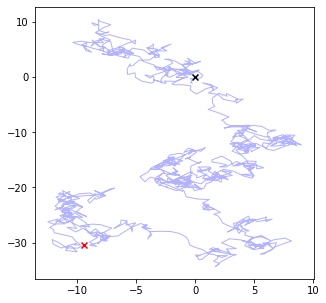

In [78]:
import numpy as np
xy = np.array([0.0,0.0]) #開始地点
T = 1000 #stepの数

# random.seed(1234) ## 同じ答えにしたければ乱数を固定しておきましょう
trajectory = []
for step in range(T):
    xy += np.array([ random.uniform(-1,1), random.uniform(-1,1)])
    trajectory += [ [ xy[0],xy[1]] ]
trajectory= np.array(trajectory).T 

fig = plt.figure(figsize=(5,5))
plt.scatter(0,0,marker="x",color="black",label="t=0")
plt.scatter(xy[0],xy[1],marker="x",color="red",label="t="+str(T))
plt.plot(trajectory[0],trajectory[1],color="blue",linewidth=1,alpha=0.3)
plt.plot()
plt.show()
plt.close()

今の場合、x方向y方向いずれも、特別な方向への指向はなく完全にランダムですが、これに獲得関数や勾配といったものが定義されると、さらなる応用ができます。

たとえば、地図に載っていない山があったと仮定して、その山の頂上にたどり着くためには、上のようなランダムウォークでは効率が悪いので、山の傾斜の情報(勾配)を利用して、その方向にランダムな大きさで進む、といった方法が思いつきますね。
大きさをランダムにすることで、局所的な峠に捕まることを避けることもできるかもしれません(場合によりけり).


進んだ注) ランダムウォークやその派生の方法は、最適化や確率分布からのサンプリングが必要な状況下でよく用いられ、統計学、自然科学、機械学習など様々な分野で活躍しています。c.f. サンプリング,マルコフ連鎖モンテカルロ法

#### $\clubsuit$ 正規分布に関して

この授業は確率・統計の授業ではないので、深入りはしませんが、正規分布(ガウス分布,ガウシアン)は我々の身の回りの様々な場所で目にする分布なので、少し触れておきます(厳密性は少々犠牲にする).